In [1]:
# Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

In [2]:
# Load the canonical processed dataset used in the original notebook
data_path = '../../data/processed/TrainingData/marriage_data_india.csv'
df = pd.read_csv(data_path)
print('Loaded:', data_path)
print('Shape:', df.shape)
df.head()

Loaded: ../../data/processed/TrainingData/marriage_data_india.csv
Shape: (10000, 13)


,Unnamed: 0,Age_at_Marriage,Gender,Education_Level,Caste_Match,Religion,Urban_Rural,Marital_Satisfaction,Divorce_Status,Income_Level,Spouse_Working,Inter-Caste,Inter-Religion
0,0,23,Male,Graduate,Different,Hindu,Urban,Medium,Yes,Middle,No,No,No
1,1,28,Female,School,Same,Hindu,Rural,Low,No,Middle,No,No,Yes
2,2,39,Male,Postgraduate,Same,Muslim,Rural,Medium,No,High,No,No,No
3,3,26,Female,School,Different,Hindu,Urban,Low,No,High,No,Yes,No
4,4,32,Female,Graduate,Same,Hindu,Rural,Medium,No,Middle,No,No,Yes


In [3]:
# Basic info and summary
print('--- Dtypes and non-null counts ---')
display(df.info())
print('''
--- Numeric summary ---''')
display(df.select_dtypes(include=np.number).describe().T)


--- Dtypes and non-null counts ---
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   Unnamed: 0            10000 non-null  int64
 1   Age_at_Marriage       10000 non-null  int64
 2   Gender                10000 non-null  str  
 3   Education_Level       10000 non-null  str  
 4   Caste_Match           10000 non-null  str  
 5   Religion              10000 non-null  str  
 6   Urban_Rural           10000 non-null  str  
 7   Marital_Satisfaction  10000 non-null  str  
 8   Divorce_Status        10000 non-null  str  
 9   Income_Level          10000 non-null  str  
 10  Spouse_Working        10000 non-null  str  
 11  Inter-Caste           10000 non-null  str  
 12  Inter-Religion        10000 non-null  str  
dtypes: int64(2), str(11)
memory usage: 1015.8 KB


None


--- Numeric summary ---


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,10000.0,4999.5000,2886.895680,0.0,2499.75,4999.5,7499.25,9999.0
Age_at_Marriage,10000.0,28.5038,6.279564,18.0,23.00,29.0,34.00,39.0


In [4]:
# Target column distribution (counts and percentages) BEFORE any oversampling
if 'target' in df.columns:
    target_counts = df['target'].value_counts(dropna=False)
    target_pct = df['target'].value_counts(normalize=True, dropna=False).mul(100).round(2)
    print('Target counts:')
    print(target_counts.to_string())
    print('''
Target percentages (%)''')
    print(target_pct.to_string())
else:
    print('No column named "target" in dataframe')
    print(' in dataframe')


No column named "target" in dataframe
 in dataframe


In [5]:
# Identify categorical columns and show value counts for each (top values)
cat_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()
print('Categorical columns found (count):', len(cat_cols))
for col in cat_cols:
    print("""
---, col, ---""")
    try:
        vc = df[col].value_counts(dropna=False).head(20)
        print(vc.to_string())
    except Exception as e:
        print('Could not compute value_counts for', col, '-', e)


Categorical columns found (count): 11

---, col, ---
Gender
Female    5109
Male      4891

---, col, ---
Education_Level
Graduate        3943
School          3073
Postgraduate    2018
PhD              966

---, col, ---
Caste_Match
Same         7071
Different    2929

---, col, ---
Religion
Hindu        6034
Muslim       1939
Christian     990
Others        531
Sikh          506

---, col, ---
Urban_Rural
Urban    6046
Rural    3954

---, col, ---
Marital_Satisfaction
Medium    5001
High      2993
Low       2006

---, col, ---
Divorce_Status
No     8999
Yes    1001

---, col, ---
Income_Level
Middle    4983
Low       2994
High      2023

---, col, ---
Spouse_Working
Yes    5047
No     4953

---, col, ---
Inter-Caste
No     7032
Yes    2968

---, col, ---
Inter-Religion
No     7972
Yes    2028


In [6]:
# Numeric columns overview: show basic stats for numeric features
num_cols = df.select_dtypes(include=np.number).columns.tolist()
print('Numeric columns (count):', len(num_cols))
display(df[num_cols].describe().T)


Numeric columns (count): 2


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,10000.0,4999.5000,2886.895680,0.0,2499.75,4999.5,7499.25,9999.0
Age_at_Marriage,10000.0,28.5038,6.279564,18.0,23.00,29.0,34.00,39.0


## Create representative testing set (as in original notebook)
The original pipeline created a held-out representative testing CSV using stratified sampling to preserve the target distribution. The code below reproduces that step and writes `Testing Data (Representative).csv` in the current working directory.

In [7]:
# Reproduce generation of a representative testing set
# Defensive: ensure X is defined from df (drop target if present)
if 'target' in df.columns:
    X = df.drop(columns=['target'])
    y = df['target']
else:
    X = df.copy()
    y = pd.Series([None]*len(df))

X_train_pool, X_new_testing, y_train_pool, y_new_testing = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42,
    stratify=y if 'target' in df.columns else None
)
df_new_testing = pd.concat([X_new_testing, y_new_testing], axis=1)
new_testing_file_name = 'Testing Data (Representative).csv'
df_new_testing.to_csv(new_testing_file_name, index=False)
print(f'New Representative Testing Data saved as: {new_testing_file_name}')
print(f'New Testing Sample Size: {df_new_testing.shape[0]} rows')


New Representative Testing Data saved as: Testing Data (Representative).csv
New Testing Sample Size: 2500 rows


## Create RWS-style oversampled training data (example)
This cell reproduces the RWS oversampling pattern used in your notebook and saves `Training Data (RWS Oversampling).csv`. It uses `RandomOverSampler` to balance minority classes to the median class size as in the original workflow.

In [8]:
# Create a simple RWS-like oversampled training dataset and save it
# Use the same stratified split used in the analysis pipeline to get a train pool
x = df.drop(columns=['target']) if 'target' in df.columns else df.copy()
y = df['target'] if 'target' in df.columns else pd.Series([None]*len(df))
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, stratify=y if 'target' in df.columns else None, random_state=42)

# Compute median class size and perform RandomOverSampler to not-majority (example approach)
if 'target' in df.columns:
    val_count = y_train.value_counts()
    median_class_size = int(val_count.median())
    sampling_strategy = {k: int(median_class_size) for k, v in val_count.items() if v < median_class_size}
    if sampling_strategy:
        ros = RandomOverSampler(sampling_strategy=sampling_strategy, random_state=42)
        x_os, y_os = ros.fit_resample(x_train, y_train)
    else:
        x_os, y_os = x_train.copy(), y_train.copy()
    rws_df_train = pd.DataFrame(x_os, columns=x_os.columns)
    rws_df_train['target'] = y_os
    rws_df_train.to_csv('Training Data (RWS Oversampling).csv', index=False)
    print('Saved Training Data (RWS Oversampling).csv with shape', rws_df_train.shape)
else:
    print('No target column present; skipping oversampling step')


No target column present; skipping oversampling step


Loaded oversampled training file from /workspaces/FinalYearProject/Matrimony_Matchmaker/notebooks/Training-Testing Dataset/Training Data (RWS Oversampling).csv
Class distribution comparison (original vs existing oversampled training file):


,orig_count,orig_pct,rws_count,rws_pct
High_No,2689,26.89,4492,16.67
High_Yes,304,3.04,4492,16.67
Low_No,1818,18.18,4492,16.67
Low_Yes,188,1.88,4492,16.67
Medium_No,4492,44.92,4492,16.67
Medium_Yes,509,5.09,4492,16.67


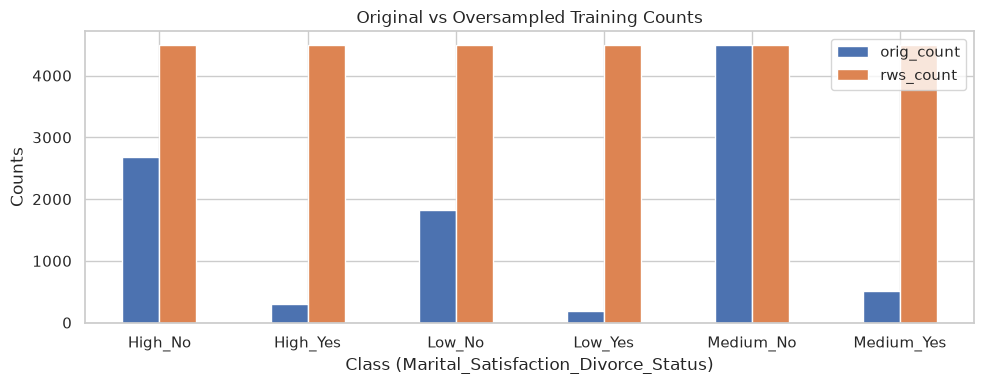

In [9]:
# Compare class distributions for the 5-class combinations (Marital_Satisfaction + Divorce_Status)
import os, pandas as pd, numpy as np, matplotlib.pyplot as plt

def make_combination_series(dfin):
    # If explicit 'target' exists, prefer it
    if 'target' in dfin.columns:
        return dfin['target'].astype(str)
    # Otherwise, try to build from Marital_Satisfaction and Divorce_Status
    if {'Marital_Satisfaction', 'Divorce_Status'}.issubset(set(dfin.columns)):
        return (dfin['Marital_Satisfaction'].astype(str).str.strip() + '_' + dfin['Divorce_Status'].astype(str).str.strip())
    raise KeyError('Neither "target" nor the pair (Marital_Satisfaction, Divorce_Status) are present in dataframe')

# Original dataset series
try:
    orig_series = make_combination_series(df)
except KeyError as e:
    print('Cannot form class combinations from original dataset:', e)
    orig_series = pd.Series(dtype=object)

orig_counts = orig_series.value_counts().sort_index()
orig_pct = orig_series.value_counts(normalize=True).mul(100).round(2).sort_index()

# Attempt to load existing oversampled training file (do not recreate)
candidate_paths = [
    'Training Data (RWS Oversampling).csv',
    os.path.join(os.getcwd(), 'Training Data (RWS Oversampling).csv'),
    '/workspaces/FinalYearProject/Matrimony_Matchmaker/notebooks/Training-Testing Dataset/Training Data (RWS Oversampling).csv',
    '/workspaces/FinalYearProject/Matrimony_Matchmaker/resources/Love-Marriage Arrange Marriage dataset/Training Data (RWS Oversampling).csv'
    ]
rws_df = None
for p in candidate_paths:
    if os.path.exists(p):
        try:
            rws_df = pd.read_csv(p)
            print('Loaded oversampled training file from', p)
            break
        except Exception as e:
            print('Found file but could not read', p, e)

if rws_df is None:
    print('No existing oversampled training CSV found in candidate locations; skipping file compare')
    rws_series = pd.Series(dtype=object)
else:
    try:
        rws_series = make_combination_series(rws_df)
    except KeyError:
        # If rws file doesn't have those columns but has 'target', try that
        if 'target' in rws_df.columns:
            rws_series = rws_df['target'].astype(str)
        else:
            print('Could not derive class combos from oversampled training file')
            rws_series = pd.Series(dtype=object)

rws_counts = rws_series.value_counts().sort_index()
rws_pct = rws_series.value_counts(normalize=True).mul(100).round(2).sort_index()

# Consolidate available series into a comparison table
compare = pd.concat([orig_counts, orig_pct, rws_counts, rws_pct], axis=1).fillna(0)
compare.columns = ['orig_count','orig_pct','rws_count','rws_pct']
for c in ['orig_count','rws_count']:
    if c in compare.columns:
        compare[c] = compare[c].astype(int)

print('Class distribution comparison (original vs existing oversampled training file):')
display(compare)

# Plot side-by-side counts if there is data
try:
    if not compare.empty:
        ax = compare[['orig_count','rws_count']].plot.bar(rot=0, figsize=(10,4))
        ax.set_xlabel('Class (Marital_Satisfaction_Divorce_Status)')
        ax.set_ylabel('Counts')
        ax.set_title('Original vs Oversampled Training Counts')
        plt.tight_layout()
        plt.show()
except Exception as e:
    print('Plotting failed:', e)


---
Notes:
- This notebook is intended as a documentation & reproducible step for the dataset splits used by your model notebooks.
- Run cells in order: imports → load → inspect → create testing set → create oversampled training set.
- The code writes two CSVs in the current working directory: `Testing Data (Representative).csv` and `Training Data (RWS Oversampling).csv`.